In [1]:
from superfv import HydroSolver, BC, ics, MUSCL_SlopeLimiter, RiemannSolver
import spd.initial_conditions as ic
from spd.sdfb_simulator import SPD_Simulator
import matplotlib as mpl
import matplotlib.pyplot as plt
from functools import partial

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams["font.size"] = 15

In [2]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

['41.96GB', '42.41GB']


In [3]:
def superfv_sim(p, N, P0=1, **kwargs):
    def gravity(idx, u, *, xp):
        gx = 0.0
        gy = 1.0
        out = xp.zeros_like(u)
        out[idx("mx")] = u[idx("rho")] * gx
        out[idx("my")] = u[idx("rho")] * gy
        out[idx("E")] = u[idx("mx")] * gx + u[idx("my")] * gy
        return out

    return HydroSolver(
        ic=partial(ics.rayleigh_taylor, gamma=5 / 3, P0=P0),
        gamma=5 / 3,
        rho_min=1e-10,
        P_min=1e-10,
        source=gravity,
        xlims=(0, 0.25),
        ylims=(0, 1),
        nx=N // 4,
        ny=N,
        bcy=(BC.REFLECTIVE, BC.REFLECTIVE),
        p=p,
        use_MOOD=True,
        use_NAD=True,
        use_SED=True,
        blend_troubles=False,
        MUSCL_limiter=MUSCL_SlopeLimiter.MONCEN,
        cupy=True,
        **kwargs,
    )

In [4]:
def spd_sim(p, N, P0=1, **kwargs):
    return SPD_Simulator(
        p=p,
        N=(N // 4, N),
        xlim=(0.0, 0.25),
        ylim=(0.0, 1.0),
        BC=(
            ("periodic", "periodic"),  # x
            ("reflective", "reflective"),  # y
        ),
        init_fct=ic.RTI(P0=1, gamma=5 / 3),
        cfl_coeff=0.4,
        use_cupy=True,
        time_integrator="rk3",
        fallback="MUSCL",
        slope_limiter="moncen",
        scheme="SDFB",
        potential=True,
        NAD="",
        PAD=True,
        SED=True,
        blending=False,
        riemann_solver_fv="hllc",  # MUSCL fallback flux
        **kwargs,
    )

In [5]:
def plot_both(fv_sim, sd_sim):
    fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, constrained_layout=True, figsize=(5, 6))

    for ax in axs:
        ax.set_aspect("equal")

    x_sd = sd_sim.regular_faces()[0]
    y_sd = sd_sim.regular_faces()[1]
    z_sd = sd_sim.transpose_to_fv(sd_sim.regular_mesh(sd_sim.dm.W_cv))[0]

    x_fv, y_fv, _ = fv_sim.mesh.faces
    z_fv = fv_sim.snapshot_history[-1].w[0, :, :, 0].T

    vmin = min(z_fv.min().item(), z_sd.min().item())
    vmax = max(z_fv.max().item(), z_sd.max().item())

    axs[0].set_title("FV4")
    axs[0].pcolormesh(cp.asnumpy(x_fv), cp.asnumpy(y_fv), z_fv, vmin=vmin, vmax=vmax)

    axs[1].set_title("SD4")
    m1 = axs[1].pcolormesh(x_sd, y_sd, z_sd, vmin=vmin, vmax=vmax)
    fig.colorbar(m1, ax=axs[1], pad=0.15)
    return fig, axs

rtol = 1e-1

In [6]:
NDOF = 192
p = 3
s1 = superfv_sim(p, NDOF, P0=1, rtol=1e-1)
s1.run(1.95)

SuperFV: 1983 steps | t=1.95e+00/1.95e+00, dt=1.42e-05 | rho_min=5.99e-01 | E_cons=1.92e+02 | wall=2.53e+01s (done)


In [7]:
N = NDOF // (p + 1)
s2 = spd_sim(p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-1, riemann_solver_sd="hllc")
s2.perform_time_evolution(1.95)

t=1.95, steps taken 3670, time taken 154.874, bzcps = 0.0


(<Figure size 500x600 with 3 Axes>,
 array([<Axes: title={'center': 'FV4'}>, <Axes: title={'center': 'SD4'}>],
       dtype=object))

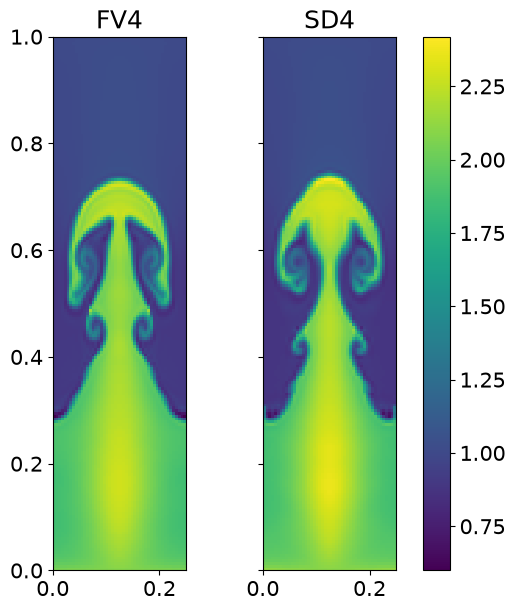

In [8]:
plot_both(s1, s2)

rtol = 1e-2

In [10]:
NDOF = 192
p = 3
s1 = superfv_sim(p, NDOF, P0=1, rtol=1e-2)
s1.run(1.95)

SuperFV: 1973 steps | t=1.95e+00/1.95e+00, dt=4.02e-04 | rho_min=6.31e-01 | E_cons=1.94e+02 | wall=2.83e+01s (done)


In [11]:
N = NDOF // (p + 1)
s2 = spd_sim(p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-2, riemann_solver_sd="hllc")
s2.perform_time_evolution(1.95)

t=1.95, steps taken 3673, time taken 155.671, bzcps = 0.0


(<Figure size 500x600 with 3 Axes>,
 array([<Axes: title={'center': 'FV4'}>, <Axes: title={'center': 'SD4'}>],
       dtype=object))

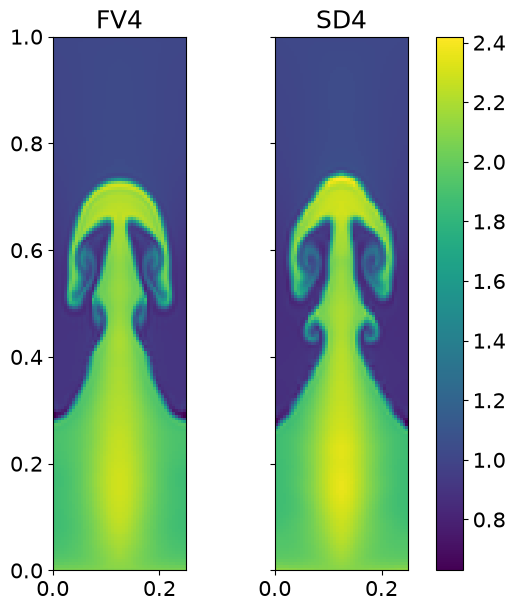

In [12]:
plot_both(s1, s2)

rtol = 1e-5

In [13]:
NDOF = 192
p = 3
s1 = superfv_sim(p, NDOF, P0=1, rtol=1e-5)
s1.run(1.95)

SuperFV: 1947 steps | t=1.95e+00/1.95e+00, dt=6.71e-04 | rho_min=8.66e-01 | E_cons=1.86e+02 | wall=2.80e+01s (done)


In [14]:
N = NDOF // (p + 1)
s2 = spd_sim(p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-5, riemann_solver_sd="hllc")
s2.perform_time_evolution(1.95)

t=1.95, steps taken 3605, time taken 152.204, bzcps = 0.0


(<Figure size 500x600 with 3 Axes>,
 array([<Axes: title={'center': 'FV4'}>, <Axes: title={'center': 'SD4'}>],
       dtype=object))

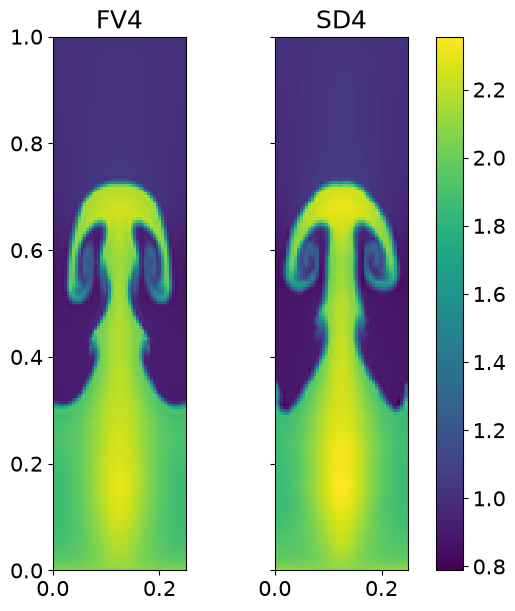

In [15]:
plot_both(s1, s2)

rtol = 1e-5, LLF for main scheme, HLLC for fallback

In [16]:
NDOF = 192
p = 3
s1 = superfv_sim(
    p,
    NDOF,
    P0=1,
    rtol=1e-5,
    riemann_solver=RiemannSolver.LLF,
    fallback_riemann_solver=RiemannSolver.HLLC,
)
s1.run(1.95)

SuperFV: 1948 steps | t=1.95e+00/1.95e+00, dt=6.75e-05 | rho_min=8.12e-01 | E_cons=1.97e+02 | wall=2.82e+01s (done)


In [17]:
N = NDOF // (p + 1)
s2 = spd_sim(p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-5, riemann_solver_sd="llf")
s2.perform_time_evolution(1.95)

t=1.95, steps taken 3613, time taken 131.903, bzcps = 0.0


(<Figure size 500x600 with 3 Axes>,
 array([<Axes: title={'center': 'FV4'}>, <Axes: title={'center': 'SD4'}>],
       dtype=object))

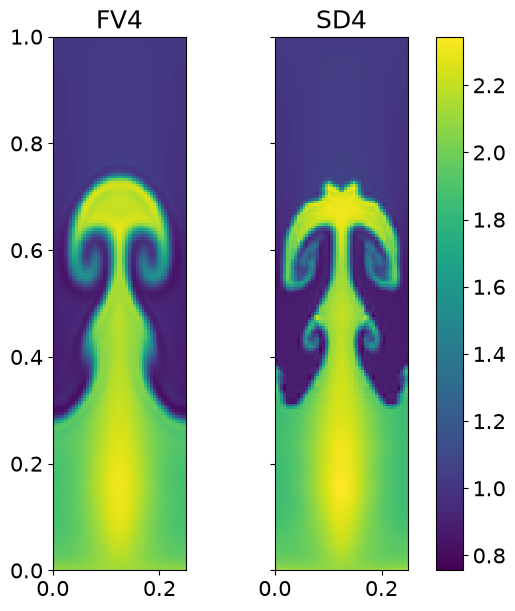

In [18]:
plot_both(s1, s2)

rtol = 1e-1, LLF for main scheme, HLLC for fallback

In [19]:
NDOF = 192
p = 3
s1 = superfv_sim(
    p,
    NDOF,
    P0=1,
    rtol=1e-1,
    riemann_solver=RiemannSolver.LLF,
    fallback_riemann_solver=RiemannSolver.HLLC,
)
s1.run(1.95)

SuperFV: 1976 steps | t=1.95e+00/1.95e+00, dt=8.46e-04 | rho_min=6.04e-01 | E_cons=1.96e+02 | wall=2.42e+01s (done)


In [20]:
N = NDOF // (p + 1)
s2 = spd_sim(p, N, P0=1, limiting_variables=[0, 1, 2, 4], tolerance=1e-1, riemann_solver_sd="llf")
s2.perform_time_evolution(1.95)

t=1.95, steps taken 4202, time taken 154.196, bzcps = 0.0


(<Figure size 500x600 with 3 Axes>,
 array([<Axes: title={'center': 'FV4'}>, <Axes: title={'center': 'SD4'}>],
       dtype=object))

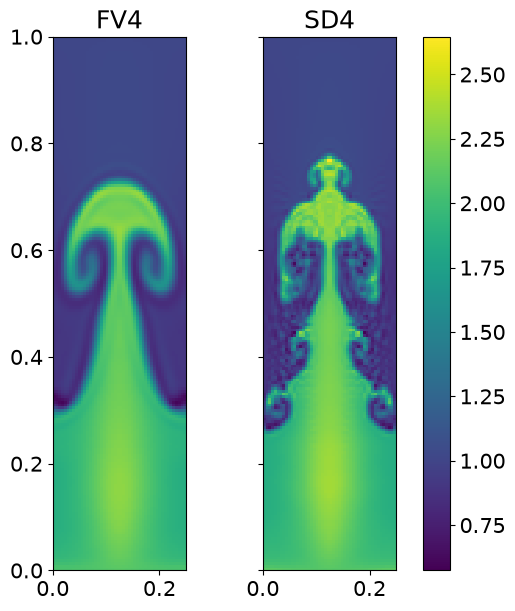

In [21]:
plot_both(s1, s2)

rtol = 1e-5, limit only on pressure and density

In [23]:
NDOF = 192
p = 3
s1 = superfv_sim(p, NDOF, P0=1, omit_vars_from_NAD=["vx", "vy", "vz"], rtol=1e-5)
s1.run(1.95)

SuperFV: 1950 steps | t=1.95e+00/1.95e+00, dt=4.74e-05 | rho_min=8.75e-01 | E_cons=1.86e+02 | wall=2.83e+01s (done)


In [24]:
N = NDOF // (p + 1)
s2 = spd_sim(p, N, P0=1, limiting_variables=[0, 4], tolerance=1e-5, riemann_solver_sd="hllc")
s2.perform_time_evolution(1.95)

t=1.95, steps taken 3606, time taken 153.586, bzcps = 0.0


(<Figure size 500x600 with 3 Axes>,
 array([<Axes: title={'center': 'FV4'}>, <Axes: title={'center': 'SD4'}>],
       dtype=object))

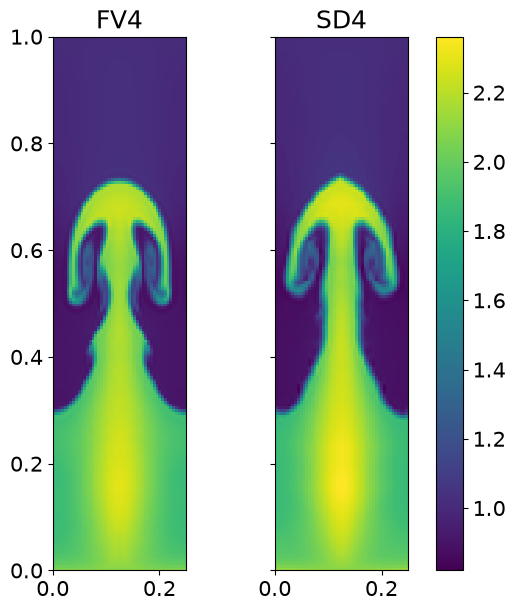

In [25]:
plot_both(s1, s2)